HOUSING PRICE PREDICTION - Chaturvi P

In [ ]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#importing the dataset and exploring
import pandas as pd

df = pd.read_csv(r"C:\Users\win11\Desktop\HousePricePrediction\Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
df.shape

(545, 13)

In [ ]:
#cleaning the dataset
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
print(df.select_dtypes(include='object').columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=False)

In [ ]:
df_encoded.head(10)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,False,True,True,False,...,False,True,False,False,True,False,True,True,False,False
1,12250000,8960,4,4,4,3,False,True,True,False,...,False,True,False,False,True,True,False,True,False,False
2,12250000,9960,3,2,2,2,False,True,True,False,...,True,True,False,True,False,False,True,False,True,False
3,12215000,7500,4,2,2,3,False,True,True,False,...,True,True,False,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,False,True,False,True,...,True,True,False,False,True,True,False,True,False,False
5,10850000,7500,3,3,1,2,False,True,True,False,...,True,True,False,False,True,False,True,False,True,False
6,10150000,8580,4,3,4,2,False,True,True,False,...,False,True,False,False,True,False,True,False,True,False
7,10150000,16200,5,3,2,0,False,True,True,False,...,False,True,False,True,False,True,False,False,False,True
8,9870000,8100,4,1,2,2,False,True,False,True,...,True,True,False,False,True,False,True,True,False,False
9,9800000,5750,3,2,4,1,False,True,False,True,...,False,True,False,False,True,False,True,False,False,True


In [ ]:
#splitting dataset into target and features
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

In [ ]:
#splitting data into training and test sets for performance evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (436, 20)
Testing set shape: (109, 20)


In [ ]:
#defining the regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
#training the model on train set
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
#testing model
y_pred_lr = model.predict(X_test)

In [ ]:
#evaluating the linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE =", mae_lr)
print("RMSE =", rmse_lr)
print("R² Score =", r2_lr)

Linear Regression Results
MAE = 970043.4039201636
RMSE = 1324506.960091438
R² Score = 0.6529242642153188


In [ ]:
#training and testing the random forest regressor model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
#evaluating the random forest regressor model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE =", mae_rf)
print("RMSE =", rmse_rf)
print("R² Score =", r2_rf)

Random Forest Results
MAE = 1025824.3793577981
RMSE = 1404074.8183960614
R² Score = 0.6099715703676805


In [ ]:
#VISUALIZATION

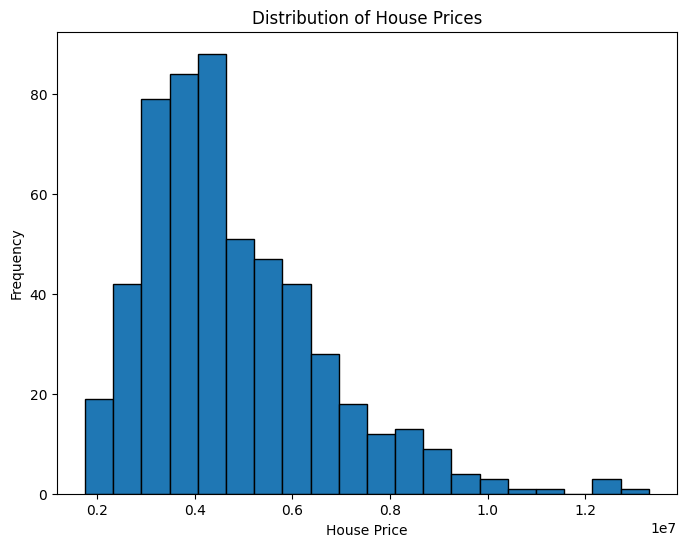

In [ ]:
#histogram
plt.figure(figsize=(8,6))

plt.hist(df['price'], bins=20, edgecolor='black')

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

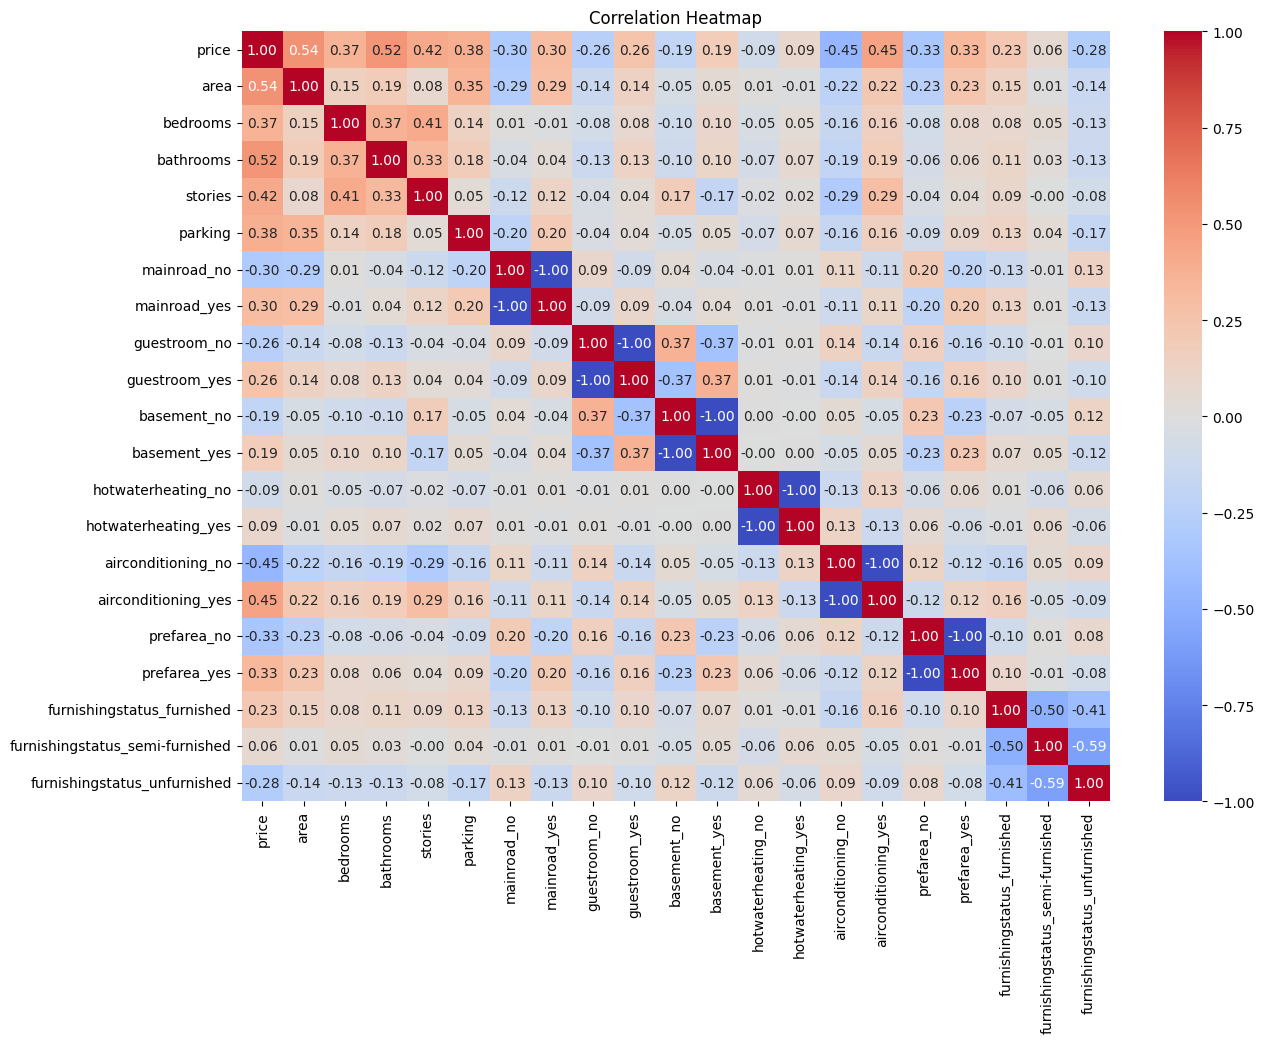

In [ ]:
#correlation table
plt.figure(figsize=(14,10))

sns.heatmap(df_encoded.corr(),
            cmap='coolwarm',
            annot=True,
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

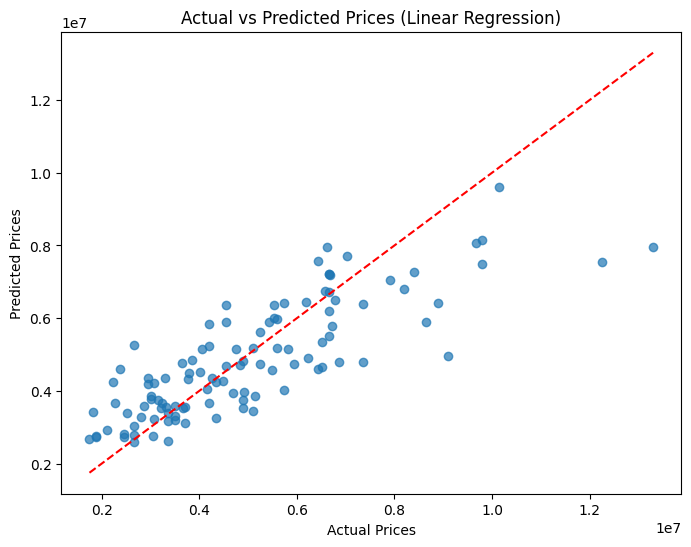

In [ ]:
#Regression Line for Linear Regression
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Linear Regression)")

plt.show()

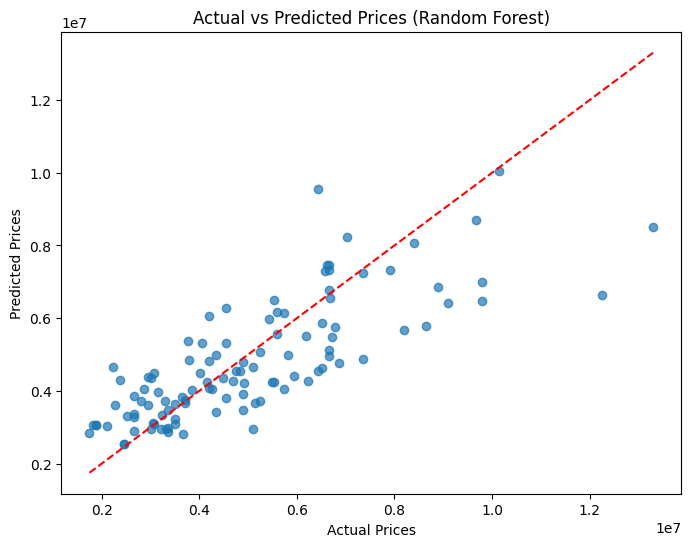

In [ ]:
#Regression Line for Random Forest
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Random Forest)")

plt.show()

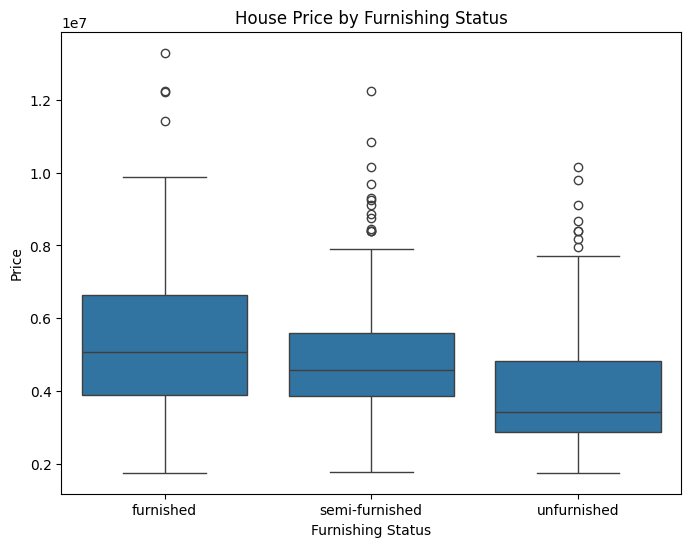

In [ ]:
#Furnishing Status vs Price box plot
plt.figure(figsize=(8,6))

sns.boxplot(
    x='furnishingstatus',
    y='price',
    data=df,

)

plt.title("House Price by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price")

plt.show()

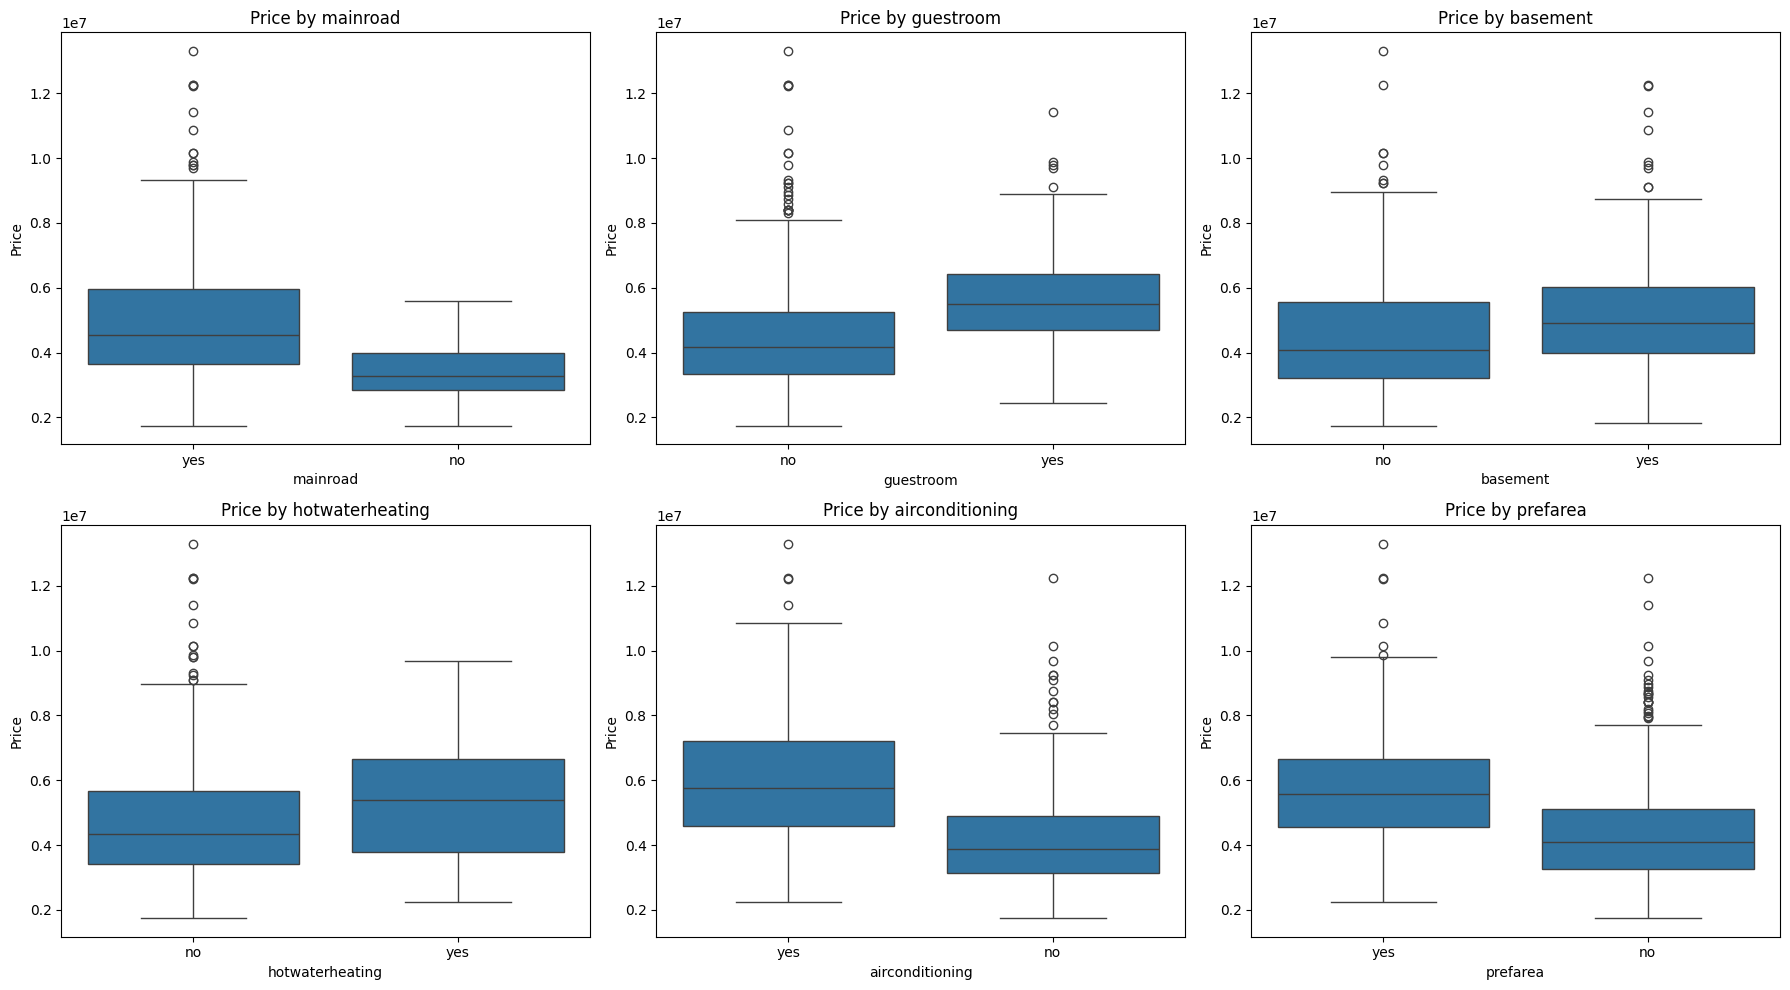

In [ ]:
#Box plot of price grouped by binary features
binary_features = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

plt.figure(figsize=(18,10))

for i, feature in enumerate(binary_features, 1):
    plt.subplot(2, 3, i)

    sns.boxplot(
        x=feature,
        y='price',
        data=df,

    )

    plt.title(f'Price by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Price')

plt.tight_layout()
plt.show()


Based on the correlation heat map price has an approx of 50% correlation to area,bathrooms,stories and air conditioning status which means that these
numbers affect the price of the house significantly whereas other features like bedroom, parking and other features had a weaker pull.
The linear regression model achieved an R² of about 0.65, with a mean average error of around Rs.9.7 lakhs
The random forest model achieved an R² of about 0.61, with a mean average error of around Rs.10 lakhs
Its surprising to see random forest achieving lower performance compared to a simple model such as linear regression, the explaination to this lies in
the fact that linear regression is a simple model and the dataset is considerable small, only 545 rows hence the more complex random forest model
overfits on the training data and fails to perform on the test data a similar thing would have happened maybe if we employed a regression model
of higher degree. Another funny yet shocking things is bathrooms correlated to price than a few other significant features which signifies that buyers
value bathrooms than functional space? A point to be noted.
From a real estate business pov prioritizing air conditioning, bathrooms and area count when selecting a property to market is crucial for a higher
success rate with a greater resale value.